## Pulling datatypes, constants and base datasets from external modules

In [4]:
import matplotlib as plt
import numpy as np
import seaborn as sns
from scipy import stats

from slide_datatypes import difficulty_colours, SlidePattern, ChartDifficulty
from base_slide_dataset import full_df, pruned_df

### Finding percentage of rows with no BPM value

In [46]:
100 * pruned_df['bpm'].isnull().sum() / len(pruned_df.index)

# pruned_df['bpm'] / pruned_df.groupby('bpm')['bpm'].transform('sum')


np.float64(4.260536811469225)

In [5]:
outlier_removed_df = pruned_df[np.abs(stats.zscore(pruned_df['star_duration'])) < 3]

outlier_removed_df

,star_duration,slide_duration,slide_delay,cw_distance,pattern_group,bpm,difficulty,version,duration_ratio,duration_with_delay,duration_with_delay_ratio
0,0.352896,1.000,0.25,3,3,130.0,6,szt,0.352896,1.250,0.282317
1,0.352896,1.000,0.25,3,2,130.0,6,szt,0.352896,1.250,0.282317
4,0.125000,0.375,0.25,3,1,130.0,6,szt,0.333333,0.625,0.200000
6,0.115485,0.375,0.25,4,1,130.0,6,szt,0.307960,0.625,0.184776
13,0.125000,0.375,0.25,5,1,130.0,6,szt,0.333333,0.625,0.200000
...,...,...,...,...,...,...,...,...,...,...,...
119893,0.106800,0.375,0.25,4,5,215.0,5,sdt,0.284800,0.625,0.170880
119896,0.202700,0.625,0.25,6,12,215.0,5,sdt,0.324320,0.875,0.231657
119897,0.202700,0.625,0.25,1,11,215.0,5,sdt,0.324320,0.875,0.231657
119898,0.202700,0.625,0.25,1,12,215.0,5,sdt,0.324320,0.875,0.231657


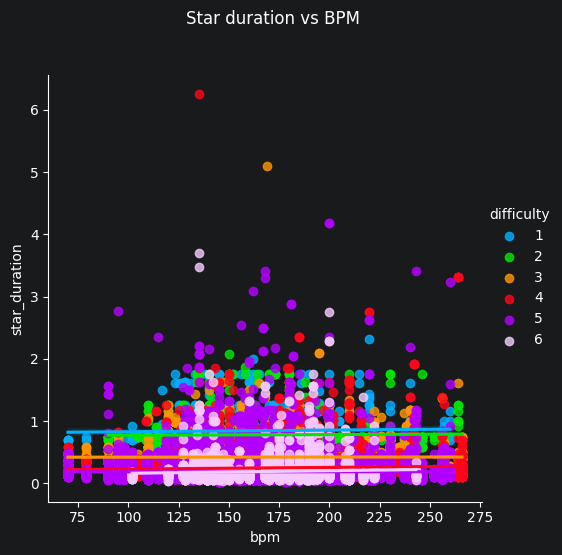

In [54]:
star_duration_bpm_correlation_plot = sns.lmplot(data=outlier_removed_df, x="bpm", y="star_duration", hue="difficulty", palette=difficulty_colours)
star_duration_bpm_correlation_plot.figure.suptitle('Star duration vs BPM', x = 0.5, y = 1.1)
    # plot.text(10, 10, 'hello')

# plot.se(30, 30)

star_duration_bpm_correlation_plot.savefig(f"pruned_slides_grouped_clockwise_difficulties_sdt+sct.png")

## Looking for simple correlations between star duration and slide duration (with / without delay)

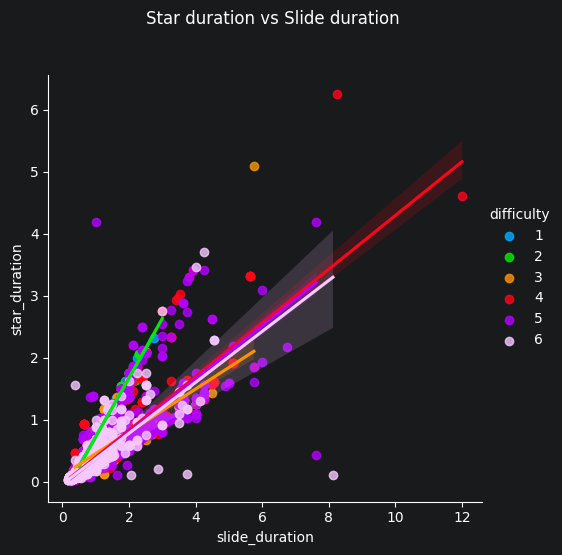

In [62]:
star_slide_duration_correlation_plot = sns.lmplot(data=outlier_removed_df, x="slide_duration", y="star_duration", hue="difficulty", palette=difficulty_colours)
star_slide_duration_correlation_plot.figure.suptitle('Star duration vs Slide duration', x = 0.5, y = 1.1)
    # plot.text(10, 10, 'hello')

# plot.se(30, 30)

star_slide_duration_correlation_plot.savefig(f"pruned_slides_grouped_clockwise_difficulties_sdt+sct.png")

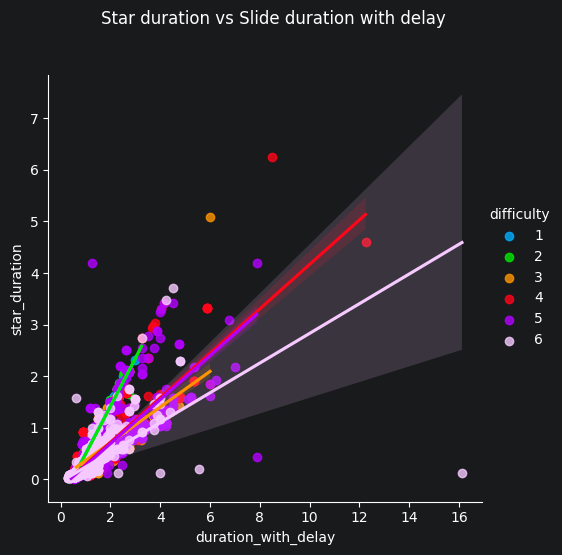

In [59]:
star_slide_with_delay_correlation_plot = sns.lmplot(data=outlier_removed_df, x="duration_with_delay", y="star_duration", hue="difficulty", palette=difficulty_colours)
star_slide_with_delay_correlation_plot.figure.suptitle('Star duration vs Slide duration with delay', x = 0.5, y = 1.1)

star_slide_with_delay_correlation_plot.savefig(f"pruned_slides_grouped_clockwise_difficulties_sdt+sct.png")

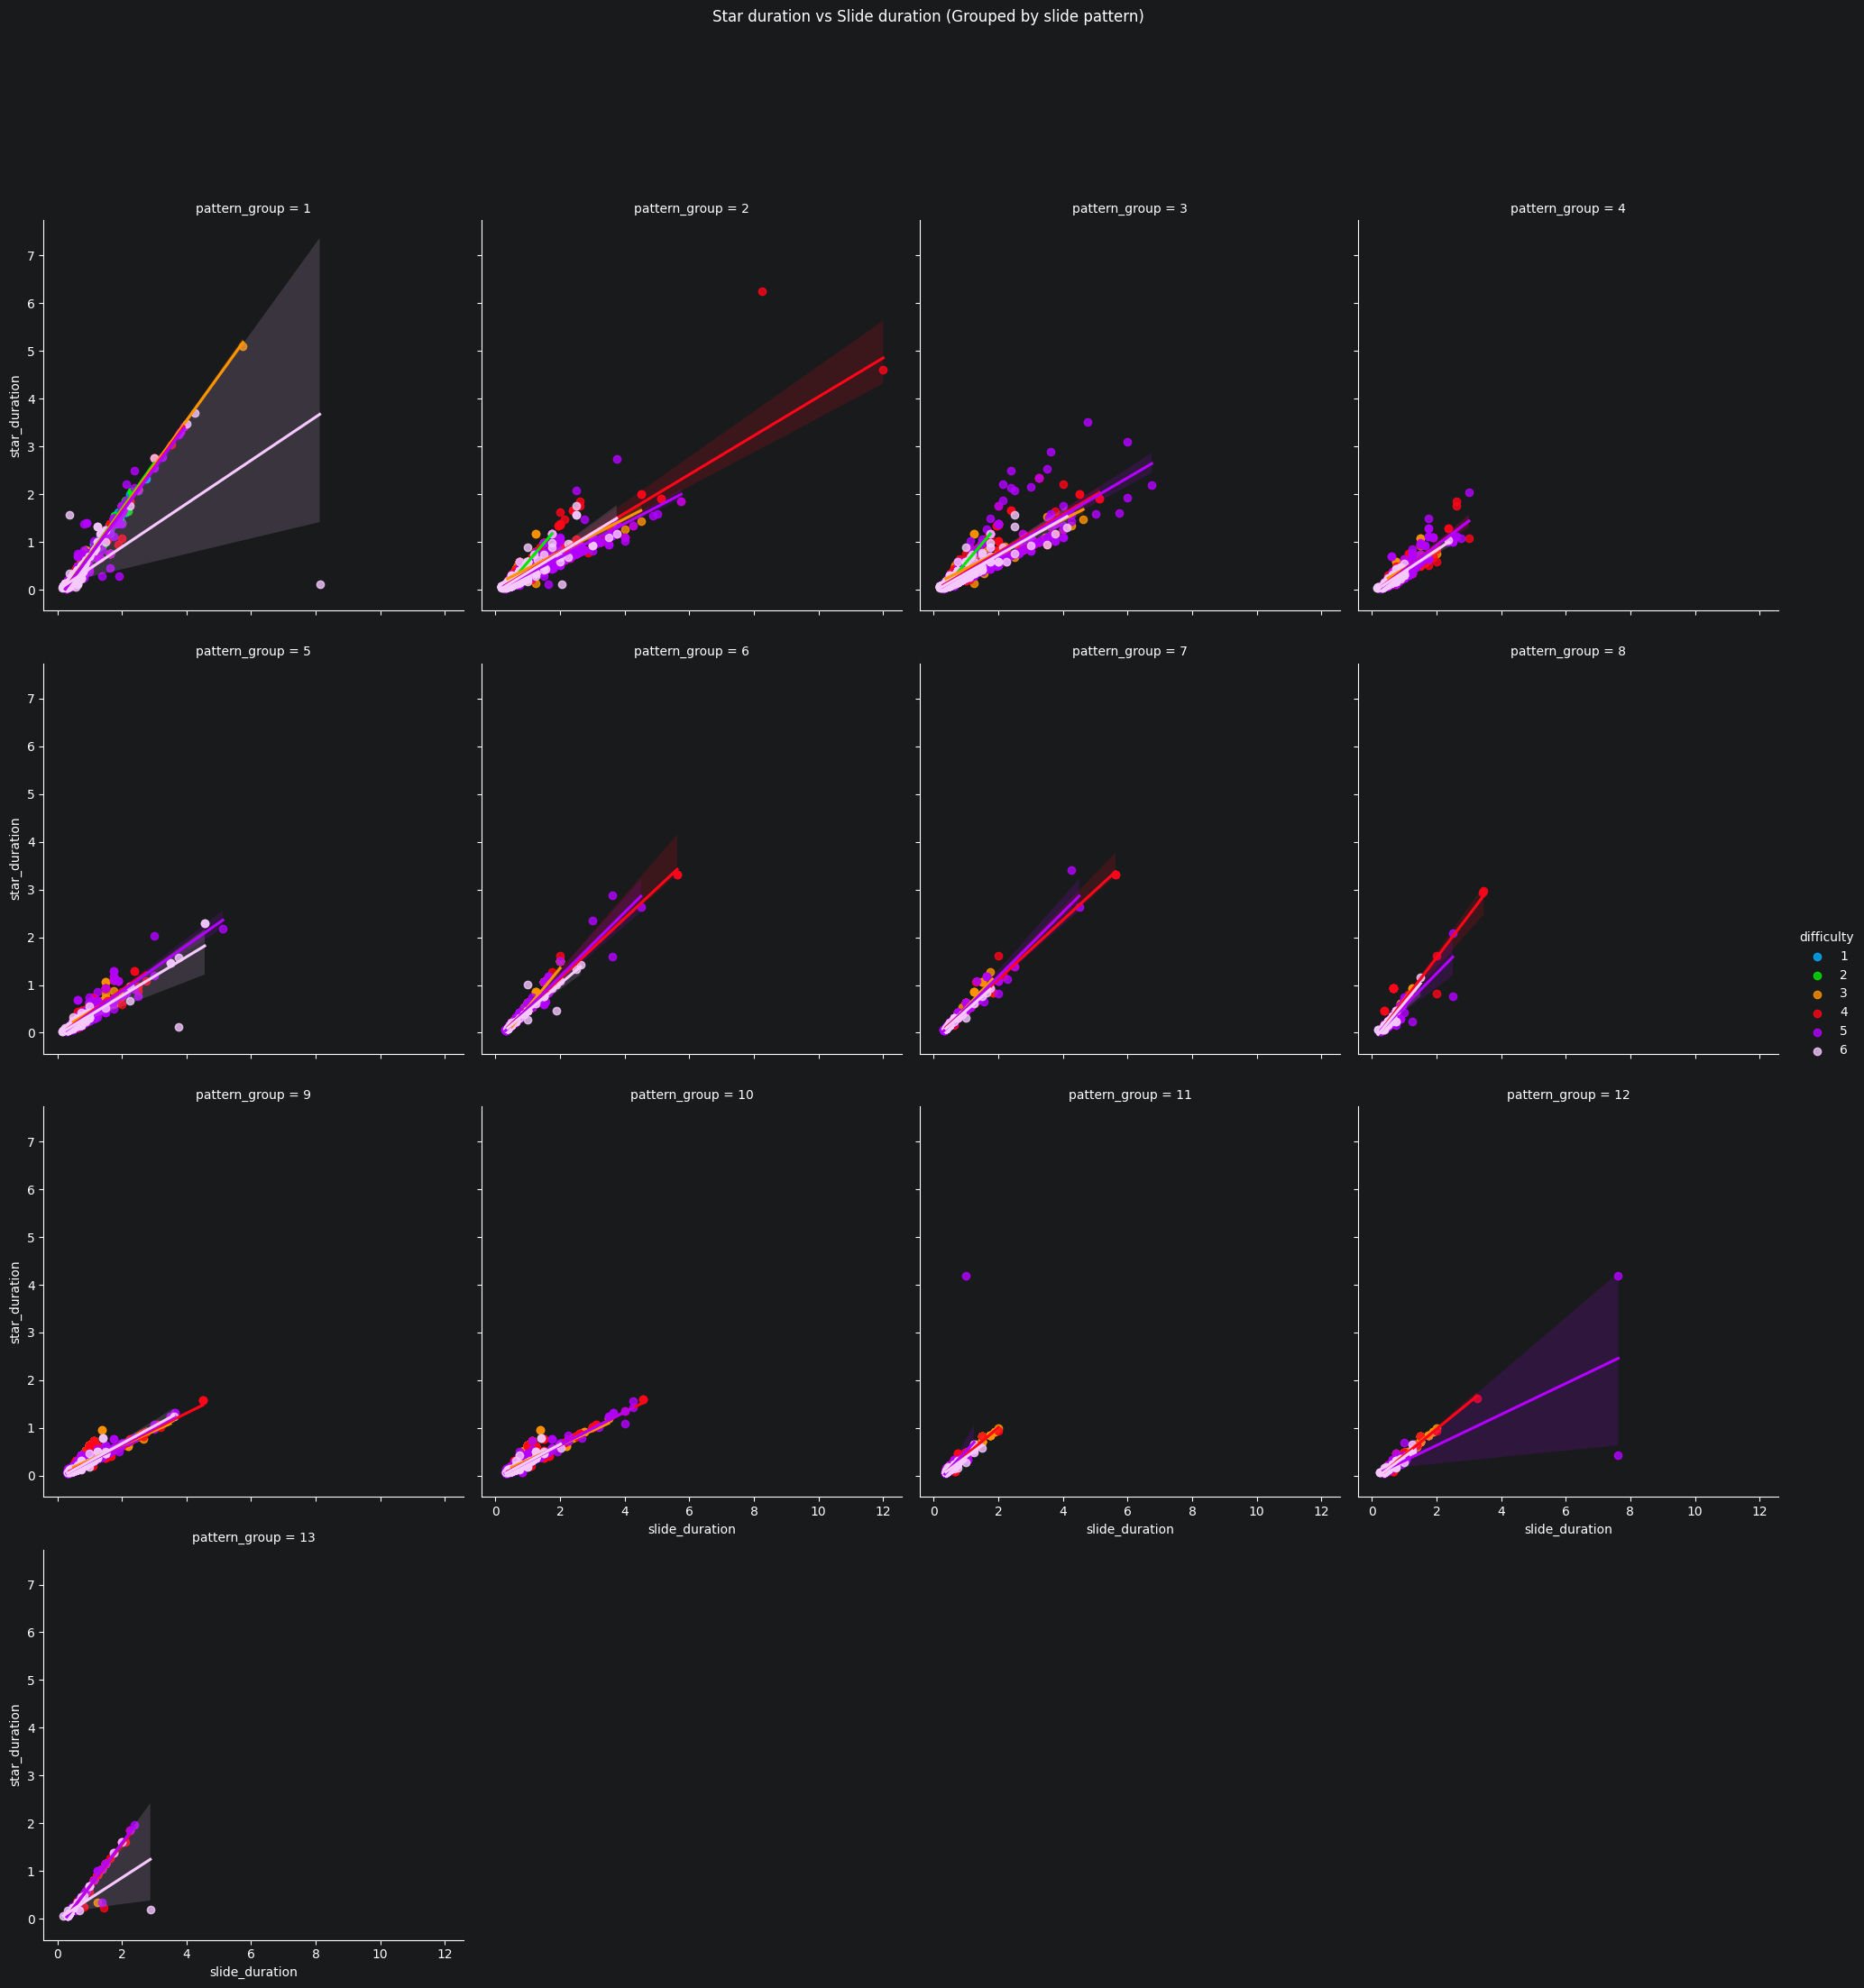

In [4]:
star_slide_duration_correlation_per_pattern_plot = sns.lmplot(data=outlier_removed_df, x="slide_duration", y="star_duration", hue="difficulty", col='pattern_group', col_wrap=4,palette=difficulty_colours)
star_slide_duration_correlation_per_pattern_plot.figure.suptitle('Star duration vs Slide duration (Grouped by slide pattern)', x = 0.5, y = 1.1)

star_slide_duration_correlation_per_pattern_plot.savefig(f"pruned_slides_grouped_clockwise_difficulties_sdt+sct.png")

C:\Users\Zestyy\OneDrive - MMU\Programming\Python\knowledge-base\.venv\Lib\site-packages\statsmodels\robust\robust_linear_model.py:289: ConvergenceWarning: Estimated scale is 0.0 indicating that the most last iteration produced a perfect fit of the weighted data.
  warnings.warn('Estimated scale is 0.0 indicating that the most'
C:\Users\Zestyy\OneDrive - MMU\Programming\Python\knowledge-base\.venv\Lib\site-packages\statsmodels\robust\robust_linear_model.py:289: ConvergenceWarning: Estimated scale is 0.0 indicating that the most last iteration produced a perfect fit of the weighted data.
  warnings.warn('Estimated scale is 0.0 indicating that the most'
C:\Users\Zestyy\OneDrive - MMU\Programming\Python\knowledge-base\.venv\Lib\site-packages\statsmodels\robust\robust_linear_model.py:289: ConvergenceWarning: Estimated scale is 0.0 indicating that the most last iteration produced a perfect fit of the weighted data.
  warnings.warn('Estimated scale is 0.0 indicating that the most'
C:\Users\Z

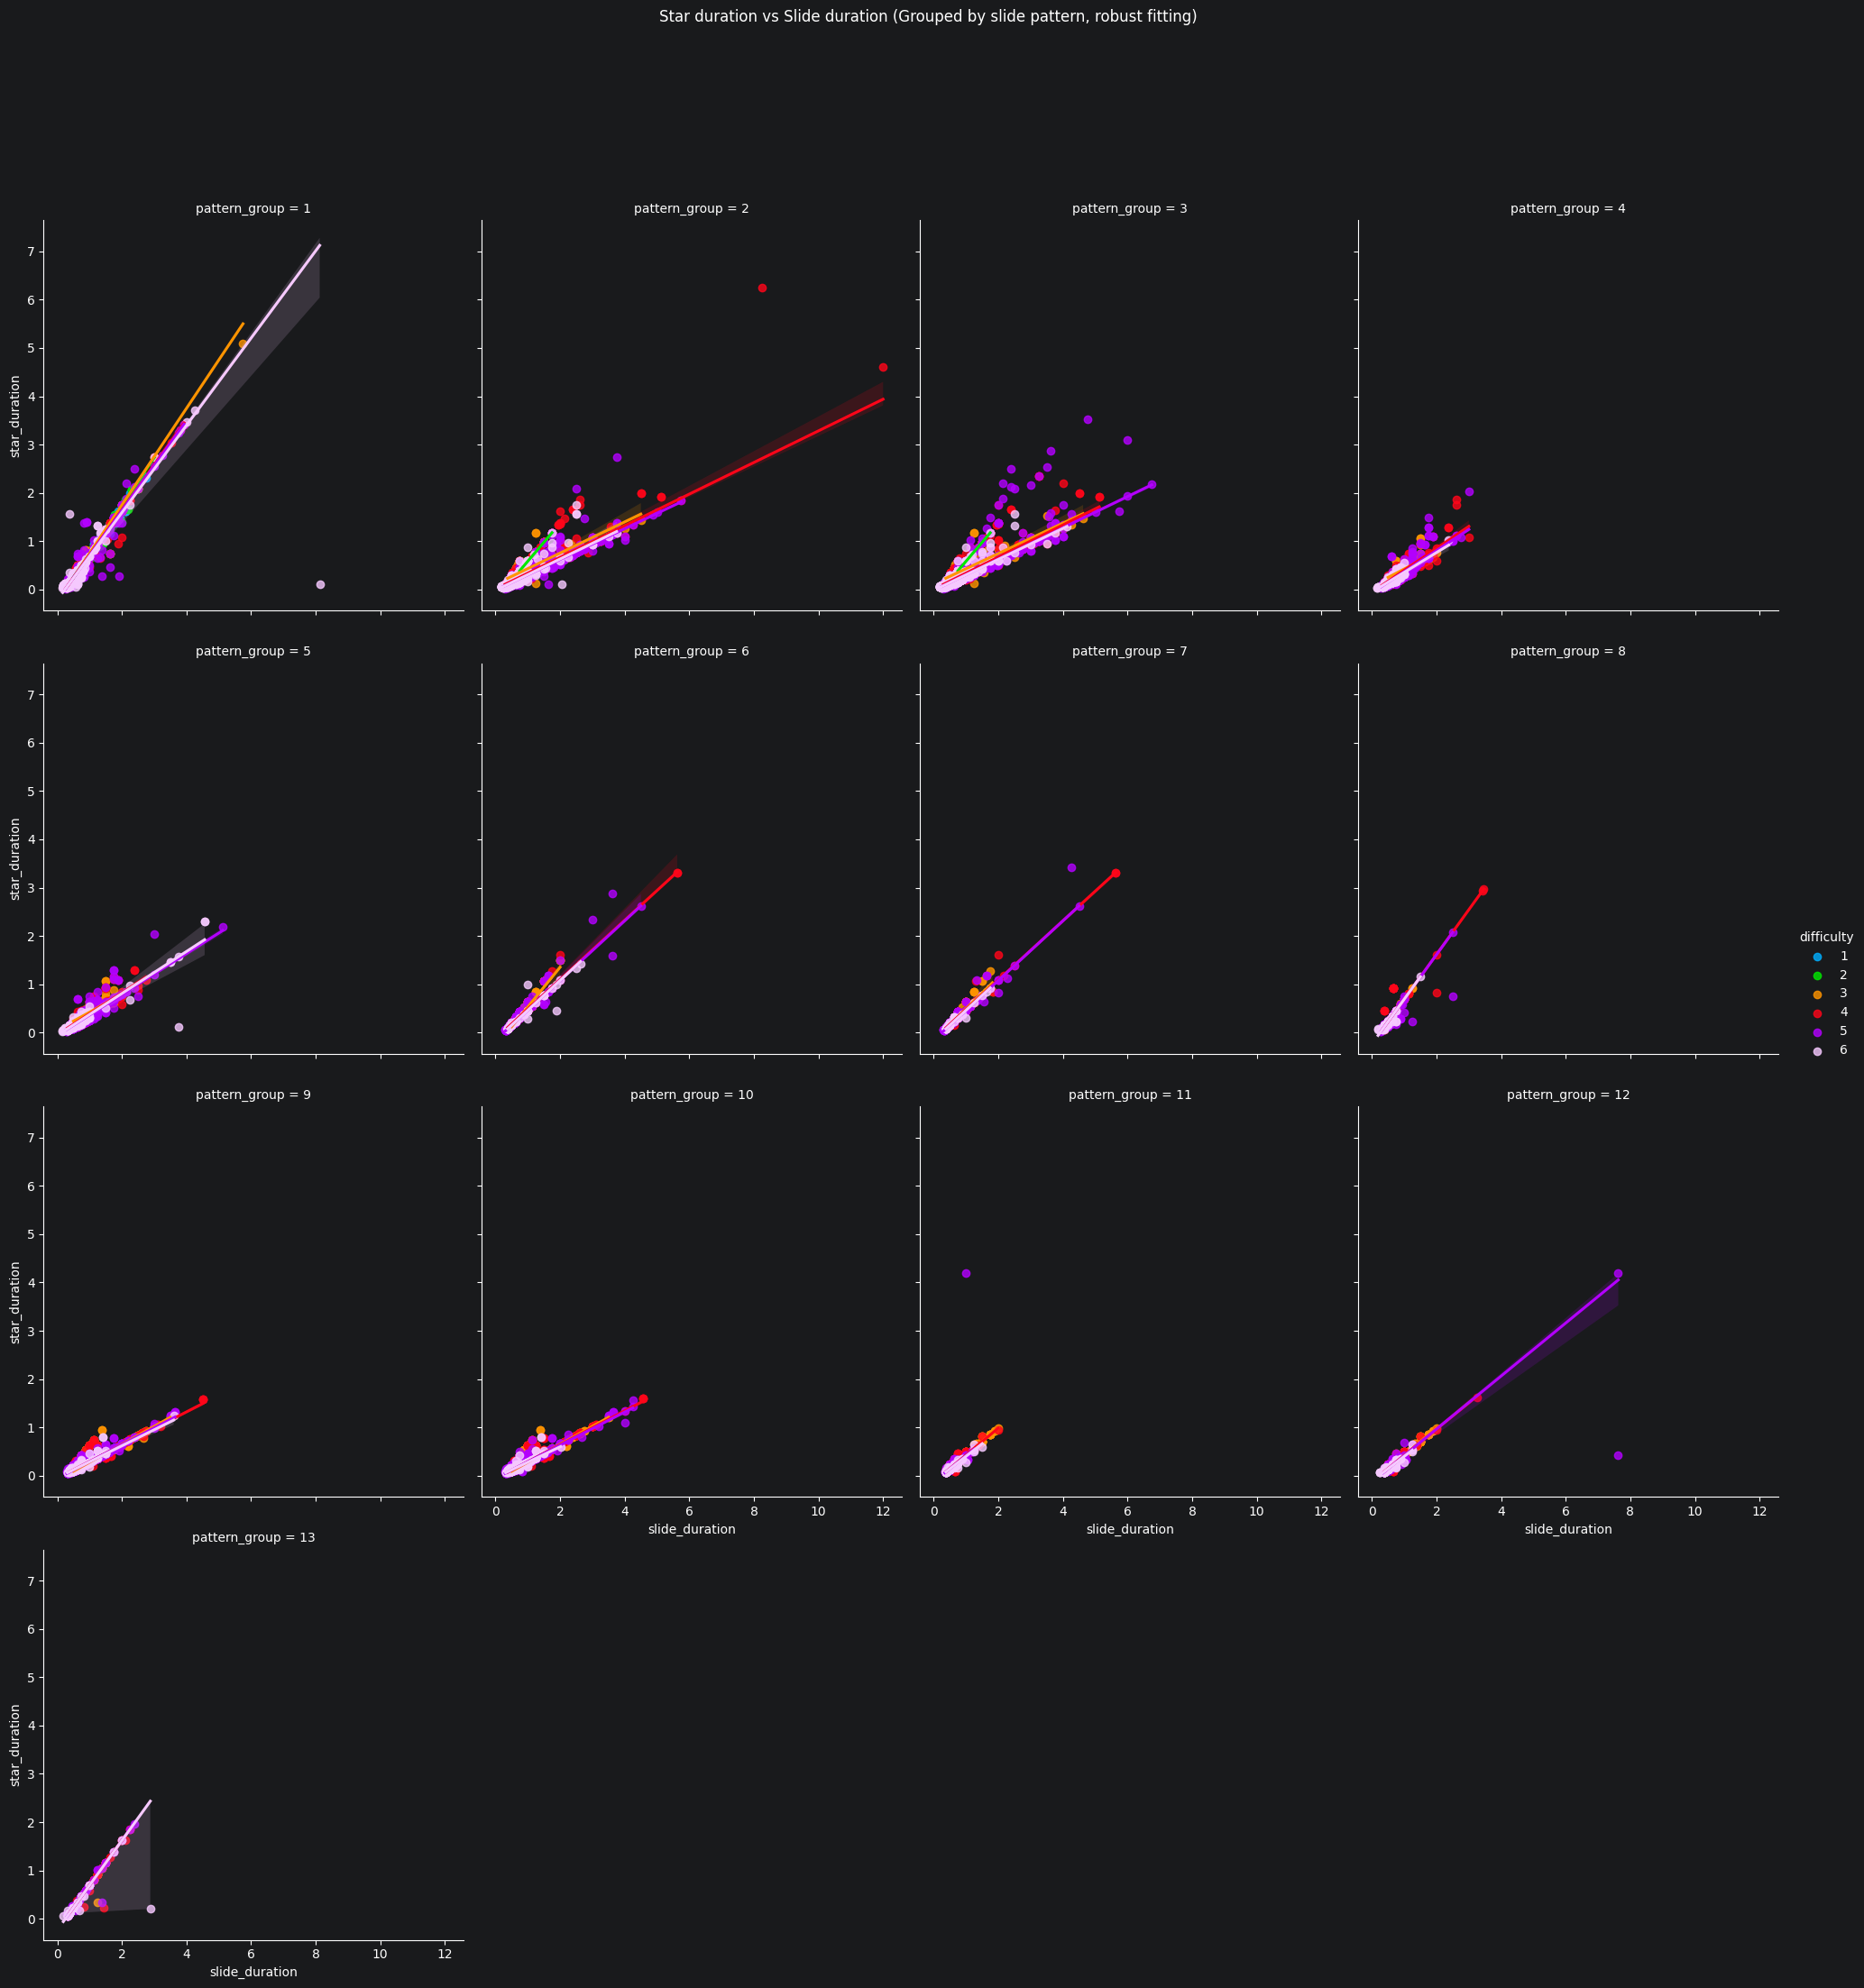

In [5]:
robust_star_slide_duration_correlation_per_pattern_plot = sns.lmplot(data=outlier_removed_df, x="slide_duration", y="star_duration", hue="difficulty", col='pattern_group', col_wrap=4, palette=difficulty_colours, robust=True)
robust_star_slide_duration_correlation_per_pattern_plot.figure.suptitle('Star duration vs Slide duration (Grouped by slide pattern, robust fitting)', x = 0.5, y = 1.1)

robust_star_slide_duration_correlation_per_pattern_plot.savefig(f"pruned_slides_grouped_clockwise_difficulties_sdt+sct.png")

## Checking for correlation in outliers for linear slides

In [2]:
master_linear_slide_df = outlier_removed_df.loc[((outlier_removed_df['pattern_group'] == 1) & (outlier_removed_df['difficulty'] == 5))]

master_linear_slide_df

NameError: name 'outlier_removed_df' is not defined

<Axes: xlabel='slide_duration', ylabel='star_duration'>

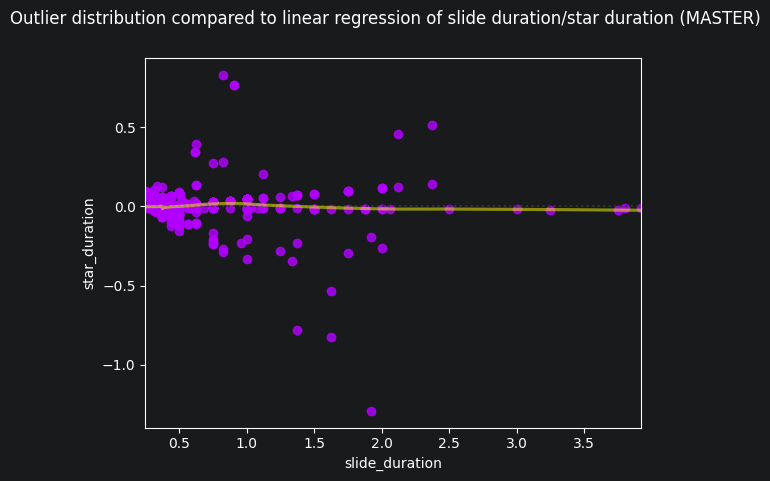

In [7]:
master_robust_linear_slide_outlier_plot = sns.residplot(data=master_linear_slide_df, x="slide_duration", y="star_duration", color=difficulty_colours[5], robust=True, lowess=True, line_kws={'color': 'yellow', 'alpha': 0.5})

master_robust_linear_slide_outlier_plot.figure.suptitle("Outlier distribution compared to linear regression of slide duration/star duration (MASTER)")

master_robust_linear_slide_outlier_plot

In [7]:
remaster_linear_slide_df = outlier_removed_df.loc[((outlier_removed_df['pattern_group'] == 1) & (outlier_removed_df['difficulty'] == 6))]

remaster_linear_slide_df

,star_duration,slide_duration,slide_delay,cw_distance,pattern_group,bpm,difficulty,version,duration_ratio,duration_with_delay,duration_with_delay_ratio
4,0.125000,0.3750,0.2500,3,1,130.0,6,szt,0.333333,0.6250,0.200000
6,0.115485,0.3750,0.2500,4,1,130.0,6,szt,0.307960,0.6250,0.184776
13,0.125000,0.3750,0.2500,5,1,130.0,6,szt,0.333333,0.6250,0.200000
128,0.125000,0.3750,0.2500,3,1,140.0,6,sdt,0.333333,0.6250,0.200000
130,0.125000,0.3750,0.2500,5,1,140.0,6,sdt,0.333333,0.6250,0.200000
...,...,...,...,...,...,...,...,...,...,...,...
116228,0.109600,0.2500,0.1667,2,1,150.0,6,sdt,0.438400,0.4167,0.263019
116229,0.109700,0.2500,0.1667,2,1,150.0,6,sdt,0.438800,0.4167,0.263259
116230,1.187500,1.3542,0.1667,3,1,150.0,6,sdt,0.876901,1.5209,0.780788
116231,1.166700,1.3333,0.1667,3,1,150.0,6,sdt,0.875047,1.5000,0.777800


<Axes: xlabel='slide_duration', ylabel='star_duration'>

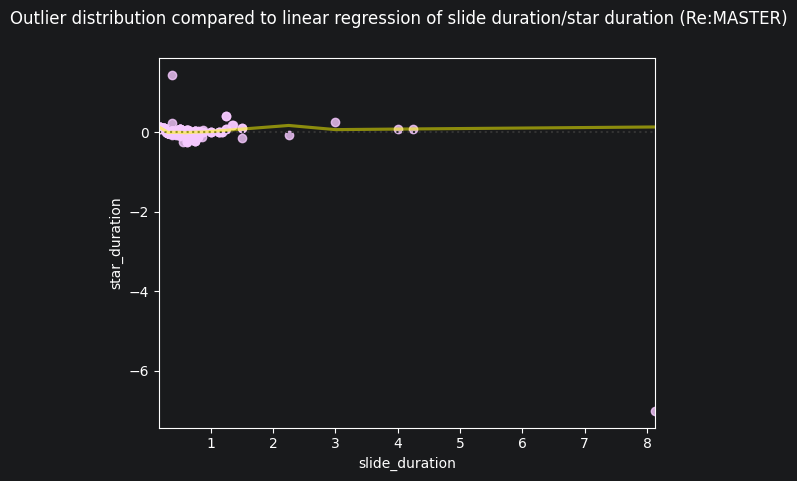

In [11]:
remaster_robust_linear_slide_outlier_plot = sns.residplot(data=remaster_linear_slide_df, x="slide_duration", y="star_duration", color=difficulty_colours[6], robust=True, lowess=True, line_kws={'color': 'yellow', 'alpha': 0.5})

remaster_robust_linear_slide_outlier_plot.figure.suptitle("Outlier distribution compared to linear regression of slide duration/star duration (Re:MASTER)")

remaster_robust_linear_slide_outlier_plot

In [1]:
from dataframe_filters import strip_values_outside_standard_deviations

filtered_master_linear_slide_df = strip_values_outside_standard_deviations(master_linear_slide_df, ['star_duration', 'slide_duration'], 3)

NameError: name 'master_linear_slide_df' is not defined

## Investigating correlations between star spin speed and distance (straight & edge of screen)

C:\Users\Zestyy\OneDrive - MMU\Programming\Python\knowledge-base\.venv\Lib\site-packages\statsmodels\robust\robust_linear_model.py:289: ConvergenceWarning: Estimated scale is 0.0 indicating that the most last iteration produced a perfect fit of the weighted data.
  warnings.warn('Estimated scale is 0.0 indicating that the most'
C:\Users\Zestyy\OneDrive - MMU\Programming\Python\knowledge-base\.venv\Lib\site-packages\statsmodels\robust\robust_linear_model.py:289: ConvergenceWarning: Estimated scale is 0.0 indicating that the most last iteration produced a perfect fit of the weighted data.
  warnings.warn('Estimated scale is 0.0 indicating that the most'
C:\Users\Zestyy\OneDrive - MMU\Programming\Python\knowledge-base\.venv\Lib\site-packages\statsmodels\robust\robust_linear_model.py:289: ConvergenceWarning: Estimated scale is 0.0 indicating that the most last iteration produced a perfect fit of the weighted data.
  warnings.warn('Estimated scale is 0.0 indicating that the most'
C:\Users\Z

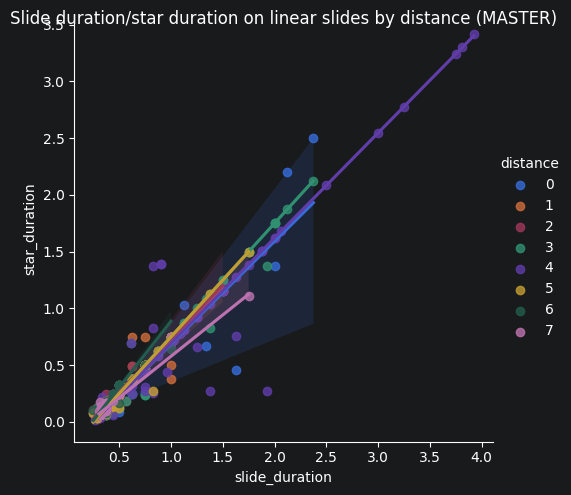

In [11]:
robust_star_slide_duration_correlation_per_pattern_plot = sns.lmplot(data=master_linear_slide_df, x="slide_duration", y="star_duration", hue="cw_distance", robust=True)

robust_star_slide_duration_correlation_per_pattern_plot.figure.suptitle("Slide duration/star duration on linear slides by cw_distance (MASTER)")

robust_star_slide_duration_correlation_per_pattern_plot

# master_linear_slide_duration_distribution_plot = sns.kdeplot(data=master_linear_slide_df, x="star_duration", y="slide_duration", hue="cw_distance")
# master_linear_slide_duration_distribution_plot

C:\Users\Zestyy\OneDrive - MMU\Programming\Python\knowledge-base\.venv\Lib\site-packages\statsmodels\robust\robust_linear_model.py:289: ConvergenceWarning: Estimated scale is 0.0 indicating that the most last iteration produced a perfect fit of the weighted data.
  warnings.warn('Estimated scale is 0.0 indicating that the most'
C:\Users\Zestyy\OneDrive - MMU\Programming\Python\knowledge-base\.venv\Lib\site-packages\statsmodels\robust\robust_linear_model.py:289: ConvergenceWarning: Estimated scale is 0.0 indicating that the most last iteration produced a perfect fit of the weighted data.
  warnings.warn('Estimated scale is 0.0 indicating that the most'
C:\Users\Zestyy\OneDrive - MMU\Programming\Python\knowledge-base\.venv\Lib\site-packages\statsmodels\robust\robust_linear_model.py:289: ConvergenceWarning: Estimated scale is 0.0 indicating that the most last iteration produced a perfect fit of the weighted data.
  warnings.warn('Estimated scale is 0.0 indicating that the most'
C:\Users\Z

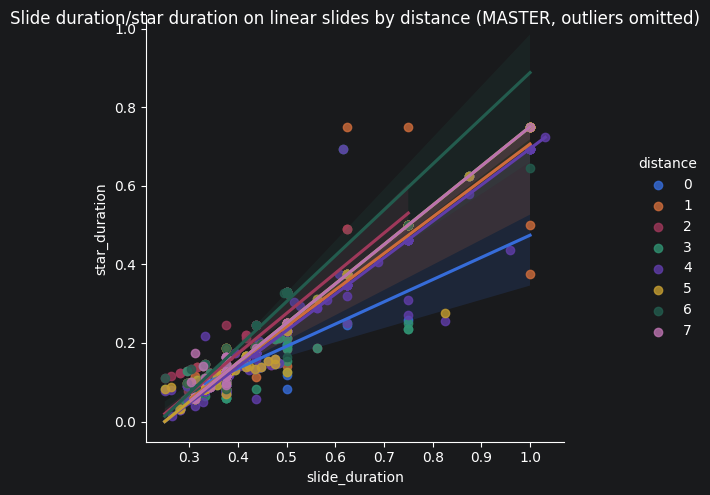

In [12]:
filtered_robust_star_slide_duration_correlation_per_pattern_plot = sns.lmplot(data=filtered_master_linear_slide_df, x="slide_duration", y="star_duration", hue="cw_distance", robust=True)

filtered_robust_star_slide_duration_correlation_per_pattern_plot.figure.suptitle("Slide duration/star duration on linear slides by cw_distance (MASTER, outliers omitted)")

filtered_robust_star_slide_duration_correlation_per_pattern_plot

In [13]:
master_ccw_edge_slide_df = outlier_removed_df.loc[((outlier_removed_df['pattern_group'] == SlidePattern.ccw_edge.value) & (outlier_removed_df['difficulty'] == ChartDifficulty.master.value))]
filtered_master_ccw_edge_slide_df = master_ccw_edge_slide_df.loc[((np.abs(stats.zscore(master_ccw_edge_slide_df['star_duration'])) < 3) & (np.abs(stats.zscore(master_ccw_edge_slide_df['slide_duration'])) < 3))]

filtered_master_ccw_edge_slide_df

,star_duration,slide_duration,slide_delay,distance,pattern_group,bpm,difficulty,version,duration_ratio,duration_with_delay,duration_with_delay_ratio
2586,0.441120,1.0000,0.25,4,2,162.0,5,szt,0.441120,1.2500,0.352896
2608,0.147040,0.5000,0.25,4,2,162.0,5,szt,0.294080,0.7500,0.196053
2614,0.196053,0.5000,0.25,3,2,162.0,5,szt,0.392106,0.7500,0.261404
2616,0.196053,0.5000,0.25,5,2,162.0,5,szt,0.392106,0.7500,0.261404
2631,0.294080,0.7500,0.25,4,2,162.0,5,szt,0.392107,1.0000,0.294080
...,...,...,...,...,...,...,...,...,...,...,...
118949,0.073500,0.3750,0.25,4,2,165.0,5,sdt,0.196000,0.6250,0.117600
119296,0.146500,0.4375,0.25,3,2,220.0,5,sdt,0.334857,0.6875,0.213091
119298,0.146500,0.4375,0.25,4,2,220.0,5,sdt,0.334857,0.6875,0.213091
119525,0.125000,0.3750,0.25,2,2,200.0,5,sdt,0.333333,0.6250,0.200000


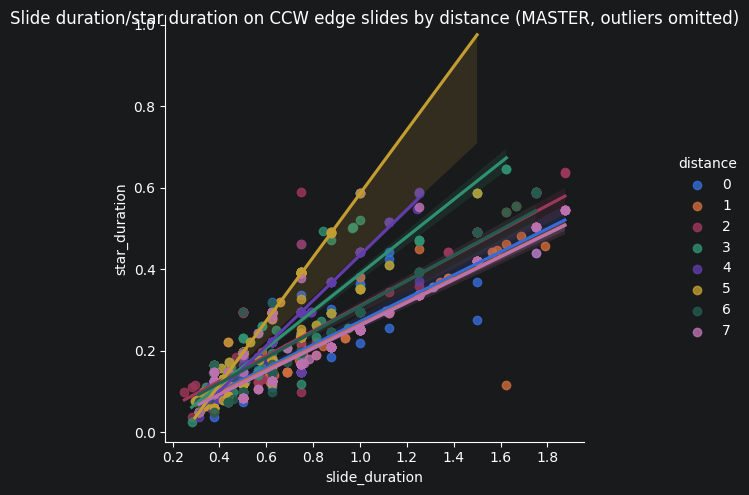

In [14]:
filtered_robust_star_slide_duration_correlation_per_pattern_plot = sns.lmplot(data=filtered_master_ccw_edge_slide_df, x="slide_duration", y="star_duration", hue="cw_distance", robust=True)

filtered_robust_star_slide_duration_correlation_per_pattern_plot.figure.suptitle("Slide duration/star duration on CCW edge slides by cw_distance (MASTER, outliers omitted)")

filtered_robust_star_slide_duration_correlation_per_pattern_plot

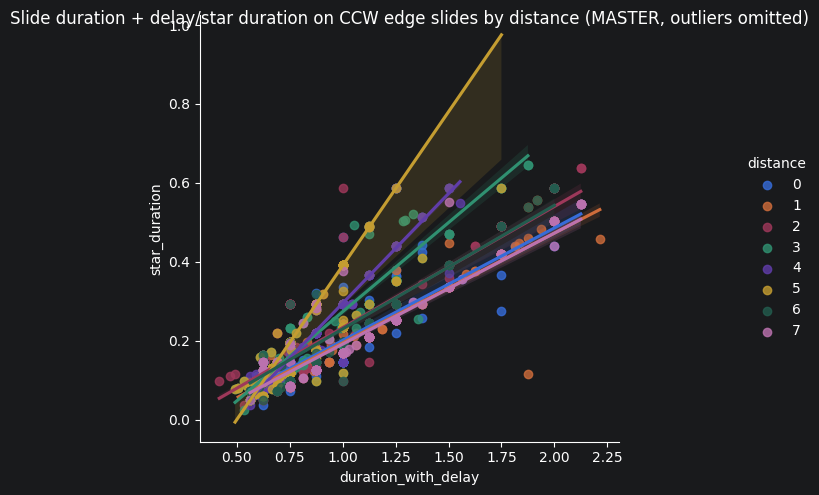

In [21]:
filtered_robust_star_slide_duration_correlation_per_pattern_plot = sns.lmplot(data=filtered_master_ccw_edge_slide_df, x="duration_with_delay", y="star_duration", hue="cw_distance", robust=True)

filtered_robust_star_slide_duration_correlation_per_pattern_plot.figure.suptitle("Slide duration + delay/star duration on CCW edge slides by cw_distance (MASTER, outliers omitted)")

filtered_robust_star_slide_duration_correlation_per_pattern_plot

In [16]:
filtered_master_ccw_edge_slide_with_bpm_df = filtered_master_ccw_edge_slide_df.loc[filtered_master_ccw_edge_slide_df['bpm'].notna()]


filtered_master_ccw_edge_slide_with_bpm_df['slide_duration_per_bpm'] = filtered_master_ccw_edge_slide_with_bpm_df['slide_duration'] / filtered_master_ccw_edge_slide_with_bpm_df['bpm']

filtered_master_ccw_edge_slide_with_bpm_df

,star_duration,slide_duration,slide_delay,distance,pattern_group,bpm,difficulty,version,duration_ratio,duration_with_delay,duration_with_delay_ratio,slide_duration_per_bpm
2586,0.441120,1.0000,0.25,4,2,162.0,5,szt,0.441120,1.2500,0.352896,0.006173
2608,0.147040,0.5000,0.25,4,2,162.0,5,szt,0.294080,0.7500,0.196053,0.003086
2614,0.196053,0.5000,0.25,3,2,162.0,5,szt,0.392106,0.7500,0.261404,0.003086
2616,0.196053,0.5000,0.25,5,2,162.0,5,szt,0.392106,0.7500,0.261404,0.003086
2631,0.294080,0.7500,0.25,4,2,162.0,5,szt,0.392107,1.0000,0.294080,0.004630
...,...,...,...,...,...,...,...,...,...,...,...,...
118949,0.073500,0.3750,0.25,4,2,165.0,5,sdt,0.196000,0.6250,0.117600,0.002273
119296,0.146500,0.4375,0.25,3,2,220.0,5,sdt,0.334857,0.6875,0.213091,0.001989
119298,0.146500,0.4375,0.25,4,2,220.0,5,sdt,0.334857,0.6875,0.213091,0.001989
119525,0.125000,0.3750,0.25,2,2,200.0,5,sdt,0.333333,0.6250,0.200000,0.001875


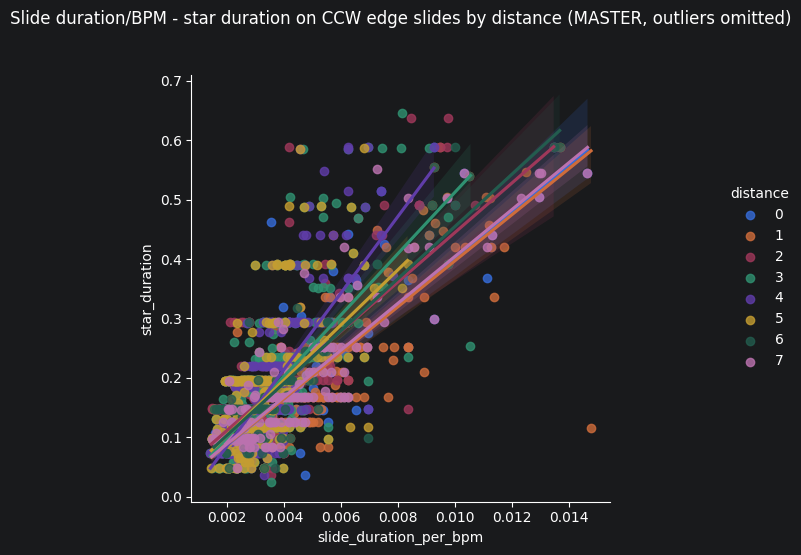

In [19]:
robust_ccw_edge_duration_correlation_with_bpm_plot = sns.lmplot(data=filtered_master_ccw_edge_slide_with_bpm_df, x="slide_duration_per_bpm", y="star_duration", hue="cw_distance", robust=True)

robust_ccw_edge_duration_correlation_with_bpm_plot.figure.suptitle("Slide duration/BPM - star duration on CCW edge slides by cw_distance (MASTER, outliers omitted)", y=1.1)

robust_ccw_edge_duration_correlation_with_bpm_plot

## Preparing data for averages by pattern, distance and difficulty

In [27]:
# Group by pattern and difficulty for filtering (since that represents a single bar for the next cell)
groups = pruned_df.groupby(['pattern_group', 'difficulty'])
# Only include data within 3 standard deviations of the mean
star_spin_without_delay_ratio_df_bar_outliers = groups.apply(lambda group: group[np.abs(stats.zscore(group['duration_ratio'])) < 3]).reset_index()

star_spin_without_delay_ratio_df_bar_outliers

,pattern_group,difficulty,level_2,star_duration,slide_duration,slide_delay,distance,version,duration_ratio,duration_with_delay,duration_with_delay_ratio
0,1,1,0,0.750000,1.000000,0.2500,3,sdt,0.750000,1.250000,0.600000
1,1,1,504,0.694445,1.000000,0.2500,4,sct,0.694445,1.250000,0.555556
2,1,1,506,0.694446,1.000002,0.2500,4,sct,0.694445,1.250002,0.555556
3,1,1,507,0.694444,1.000000,0.2500,4,sct,0.694444,1.250000,0.555555
4,1,1,508,0.694449,1.000000,0.2500,4,sct,0.694449,1.250000,0.555559
...,...,...,...,...,...,...,...,...,...,...,...
14530,13,6,59773,0.477600,0.810600,0.2948,4,sdt,0.589193,1.105400,0.432061
14531,13,6,91751,0.347200,0.625000,0.2500,4,sdt,0.555520,0.875000,0.396800
14532,13,6,92170,1.620370,1.999996,0.2500,4,sct,0.810187,2.249996,0.720166
14533,13,6,94746,0.115738,0.375000,0.2500,4,sct,0.308635,0.625000,0.185181


In [28]:
# Only include data within 3 standard deviations of the mean
star_spin_with_delay_ratio_df_bar_outliers = groups.apply(lambda group: group[np.abs(stats.zscore(group['duration_with_delay_ratio'])) < 3]).reset_index()

star_spin_with_delay_ratio_df_bar_outliers

,pattern_group,difficulty,level_2,star_duration,slide_duration,slide_delay,distance,version,duration_ratio,duration_with_delay,duration_with_delay_ratio
0,1,1,0,0.750000,1.000000,0.2500,3,sdt,0.750000,1.250000,0.600000
1,1,1,504,0.694445,1.000000,0.2500,4,sct,0.694445,1.250000,0.555556
2,1,1,506,0.694446,1.000002,0.2500,4,sct,0.694445,1.250002,0.555556
3,1,1,507,0.694444,1.000000,0.2500,4,sct,0.694444,1.250000,0.555555
4,1,1,508,0.694449,1.000000,0.2500,4,sct,0.694449,1.250000,0.555559
...,...,...,...,...,...,...,...,...,...,...,...
14463,13,6,59773,0.477600,0.810600,0.2948,4,sdt,0.589193,1.105400,0.432061
14464,13,6,91751,0.347200,0.625000,0.2500,4,sdt,0.555520,0.875000,0.396800
14465,13,6,92170,1.620370,1.999996,0.2500,4,sct,0.810187,2.249996,0.720166
14466,13,6,94746,0.115738,0.375000,0.2500,4,sct,0.308635,0.625000,0.185181


In [29]:
star_spin_ratio_normalised_df_bar_outliers = groups.apply(lambda group: group[np.abs(stats.zscore(group['duration_ratio'])) < 3]).reset_index()

star_spin_ratio_normalised_df_bar_outliers = star_spin_ratio_normalised_df_bar_outliers.loc[star_spin_ratio_normalised_df_bar_outliers['star_duration'] == 1]

star_spin_ratio_normalised_df_bar_outliers

,pattern_group,difficulty,level_2,star_duration,slide_duration,slide_delay,distance,version,duration_ratio,duration_with_delay,duration_with_delay_ratio
16,1,1,5414,1.0,1.250000,0.25,3,sdt,0.800000,1.500000,0.666667
21,1,1,6636,1.0,1.250000,0.25,3,szt,0.800000,1.500000,0.666667
22,1,1,6642,1.0,1.250000,0.25,3,sct,0.800000,1.500000,0.666667
64,1,1,23961,1.0,1.249996,0.25,3,sct,0.800003,1.499996,0.666668
65,1,1,23962,1.0,1.250004,0.25,3,sct,0.799997,1.500004,0.666665
92,1,1,37562,1.0,1.250000,0.25,5,sdt,0.800000,1.500000,0.666667
117,1,1,59060,1.0,1.250002,0.25,3,sct,0.799999,1.500002,0.666666
151,1,1,95485,1.0,1.250000,0.25,4,szt,0.800000,1.500000,0.666667
208,1,2,11201,1.0,1.250000,0.25,5,szt,0.800000,1.500000,0.666667
209,1,2,11203,1.0,1.250000,0.25,3,szt,0.800000,1.500000,0.666667


In [32]:
correlatable_df = pruned_df.drop(axis=1, labels=['version'])

correlatable_df.corrwith(correlatable_df['star_duration'])

star_duration                1.000000
slide_duration               0.007299
slide_delay                 -0.000398
distance                     0.001099
pattern_group               -0.012143
difficulty                  -0.035584
duration_ratio               0.999998
duration_with_delay          0.007052
duration_with_delay_ratio    0.999998
dtype: float64

## Defining slide patterns that are similar to one another

In [ ]:
pattern_groups: tuple[tuple[str, tuple[SlidePattern, ...]], ...] = (
    ('Straight Line', (SlidePattern.straight,)),
    ('Edge Circle', (SlidePattern.cw_edge, SlidePattern.ccw_edge)),
    ('Centre Arc', (SlidePattern.cw_centre_arc, SlidePattern.ccw_centre_arc)),
    ('Zigzag', (SlidePattern.zigzag_s, SlidePattern.zigzag_z)),
    ('Straight - Centre - End', (SlidePattern.straight_centre_end,)),
    ('Straight - Arc - End', (SlidePattern.straight_centre_ccw_end, SlidePattern.straight_centre_cw_end)),
    ('Grand V', (SlidePattern.ccw_grand_v, SlidePattern.cw_grand_v)),
    ('Fan', (SlidePattern.fan,))
)

In [ ]:
# sns.color_palette(difficulty_colours)

duration_at_one_star_duration_bar_fig, duration_at_one_star_bar_axs = plt.subplots(ncols=4, nrows=4)
duration_at_one_star_duration_bar_fig.suptitle('TODO', size='xx-large')

# TODO: Find charts with incorrect zigzag Zs
# TODO: Look into why chart is flipped between pattern CW and CCW (are calculations for cw_distance correct?)

for count, pattern_group in enumerate(SlidePattern):
    pattern_df = star_spin_without_delay_ratio_df_bar_outliers.loc[star_spin_without_delay_ratio_df_bar_outliers['pattern_group'] == pattern_group]

    plot = sns.barplot(data=pattern_df, x="cw_distance", y="slide_duration", hue="difficulty", palette=difficulty_colours,
                       ax=duration_at_one_star_bar_axs[count // 4][count % 4]).set(title=pattern_group.name)

duration_at_one_star_duration_bar_fig.set_size_inches(30, 30)

duration_at_one_star_duration_bar_fig.savefig(f"pruned_slides_grouped_clockwise_difficulties_sdt+sct.png")

## Visualising slides by pattern, distance and difficulty

In [ ]:
difficulty_colours = {
    1: '#00afff',
    2: '#00e800',
    3: '#ff9400',
    4: '#ff0519',
    5: '#b300ff',
    6: '#f6c9ff',
}

# sns.color_palette(difficulty_colours)

duration_ratio_bar_fig, duration_bar_axs = plt.subplots(ncols=4, nrows=4)
duration_ratio_bar_fig.suptitle('Star spin speed multiplier by pattern, cw_distance and difficulty (Clockwise Distance, SZT + SCT + SZT)', size='xx-large')

# TODO: Find charts with incorrect zigzag Zs
# TODO: Look into why chart is flipped between pattern CW and CCW (are calculations for cw_distance correct?)

for count, pattern_group in enumerate(SlidePattern):
    pattern_df = star_spin_without_delay_ratio_df_bar_outliers.loc[star_spin_without_delay_ratio_df_bar_outliers['pattern_group'] == pattern_group]

    plot = sns.barplot(data=pattern_df, x="cw_distance", y="duration_ratio", hue="difficulty", palette=difficulty_colours,
                       ax=duration_bar_axs[count // 4][count % 4]).set(title=pattern_group.name)

duration_ratio_bar_fig.set_size_inches(30, 30)

duration_ratio_bar_fig.savefig(f"pruned_slides_grouped_clockwise_difficulties_sdt+sct.png")

In [ ]:
duration_with_delay_ratio_bar_fig, duration_bar_axs = plt.subplots(ncols=4, nrows=4)
duration_with_delay_ratio_bar_fig.suptitle('Star spin speed multiplier with delay by pattern, cw_distance and difficulty (Clockwise Distance, SZT + SCT + SZT)', size='xx-large')

# TODO: Find charts with incorrect zigzag Zs
# TODO: Look into why chart is flipped between pattern CW and CCW (are calculations for cw_distance correct?)

for count, pattern_group in enumerate(SlidePattern):
    pattern_df = star_spin_with_delay_ratio_df_bar_outliers.loc[star_spin_with_delay_ratio_df_bar_outliers['pattern_group'] == pattern_group]

    plot = sns.barplot(data=pattern_df, x="cw_distance", y="duration_ratio", hue="difficulty", palette=difficulty_colours,
                       ax=duration_bar_axs[count // 4][count % 4]).set(title=pattern_group.name)

duration_with_delay_ratio_bar_fig.set_size_inches(30, 30)

duration_with_delay_ratio_bar_fig.savefig(f"pruned_slides_grouped_clockwise_difficulties_sdt+sct.png")

In [ ]:
duration_bar_fig, duration_bar_axs = plt.subplots(ncols=4, nrows=4)
duration_bar_fig.suptitle('Star spin speed by pattern, cw_distance and difficulty (Clockwise Distance, SZT + SCT + SZT)', size='xx-large')

# TODO: Find charts with incorrect zigzag Zs
# TODO: Look into why chart is flipped between pattern CW and CCW (are calculations for cw_distance correct?)

for count, pattern_group in enumerate(SlidePattern):
    pattern_df = star_spin_with_delay_ratio_df_bar_outliers.loc[star_spin_with_delay_ratio_df_bar_outliers['pattern_group'] == pattern_group]

    plot = sns.barplot(data=pattern_df, x="cw_distance", y="star_duration", hue="difficulty", palette=difficulty_colours,
                       ax=duration_bar_axs[count // 4][count % 4]).set(title=pattern_group.name)

duration_bar_fig.set_size_inches(30, 30)

duration_bar_fig.savefig(f"pruned_slides_grouped_clockwise_difficulties_sdt+sct.png")

## TODO: Graph data including delay for spin ratio, move graphing code to functions where possible

In [ ]:
# correlation_fig, correlation_axs = plt.subplots(ncols=4, nrows=4)
# correlation_fig.suptitle('Correlation between duration ratio and slide length', size='xx-large')

# for count, pattern_group in enumerate(SlidePattern):
#     pattern_df = star_spin_with_delay_ratio_df_bar_outliers.loc[star_spin_with_delay_ratio_df_bar_outliers['pattern_group'] == pattern_group]

plot = sns.lmplot(data=star_spin_with_delay_ratio_df_bar_outliers, x="cw_distance", y="duration_with_delay_ratio", hue="difficulty", palette=difficulty_colours,
                   col='pattern_group')
plot.figure.suptitle('Duration ratio with delay vs length', x = 0.5, y = 1.1)
    # plot.text(10, 10, 'hello')

# plot.se(30, 30)

plot.savefig(f"pruned_slides_grouped_clockwise_difficulties_sdt+sct.png")

In [ ]:
plot = sns.lmplot(data=star_spin_without_delay_ratio_df_bar_outliers, x="cw_distance", y="duration_ratio", hue="difficulty", palette=difficulty_colours,
                   col='pattern_group')
plot.figure.suptitle('Duration ratio without delay vs length', x = 0.5, y = 1.1)
    # plot.text(10, 10, 'hello')

# plot.se(30, 30)

plot.savefig(f"pruned_slides_grouped_clockwise_difficulties_sdt+sct.png")